# kNN Collaborative Filtering

This notebook builds an item-item k-nearest neighbors recommender on `ratings.csv` and uses it to recommend movies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

print(f'ratings: {ratings.shape[0]:,} rows')
print(f'movies: {movies.shape[0]:,} rows')
ratings.head()

ratings: 100,836 rows
movies: 9,742 rows


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Prepare the rating matrix

We map the original `userId` and `movieId` values into dense row/column indexes. For item-item kNN, each movie becomes a vector of user-centered ratings.

users: 610
movies with ratings: 9,724
train ratings: 80,712
test ratings: 20,124
global mean rating: 3.502


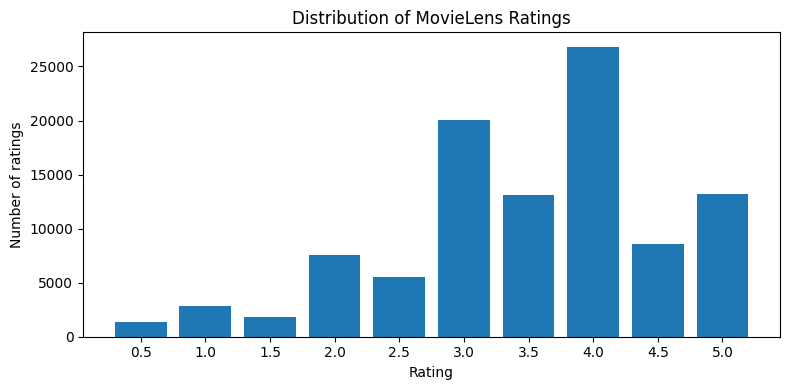

In [2]:
rng = np.random.default_rng(42)

user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}
idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}

ratings = ratings.assign(
    user_idx=ratings['userId'].map(user_to_idx),
    movie_idx=ratings['movieId'].map(movie_to_idx),
)

split_mask = rng.random(len(ratings)) < 0.8
train = ratings.loc[split_mask].reset_index(drop=True)
test = ratings.loc[~split_mask].reset_index(drop=True)

n_users = len(user_to_idx)
n_movies = len(movie_to_idx)
global_mean = train['rating'].mean()

print(f'users: {n_users:,}')
print(f'movies with ratings: {n_movies:,}')
print(f'train ratings: {len(train):,}')
print(f'test ratings: {len(test):,}')
print(f'global mean rating: {global_mean:.3f}')

rating_counts = ratings['rating'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title('Distribution of MovieLens Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of ratings')
plt.tight_layout()
plt.show()

In [3]:
print(train.head())
print(train.iloc[0])

   userId  movieId  rating  timestamp  user_idx  movie_idx
0       1        1     4.0  964982703         0          0
1       1        3     4.0  964981247         0          1
2       1       47     5.0  964983815         0          3
3       1       50     5.0  964982931         0          4
4       1      101     5.0  964980868         0          6
userId               1.0
movieId              1.0
rating               4.0
timestamp    964982703.0
user_idx             0.0
movie_idx            0.0
Name: 0, dtype: float64


## Build an item-item kNN model

The model compares movies by cosine similarity. Ratings are centered by each user's mean so the similarity focuses on taste patterns instead of users who simply rate everything high or low.

In [4]:
def build_item_knn(train, n_users, n_movies):
    rating_matrix = np.zeros((n_users, n_movies), dtype=np.float32)
    rating_matrix[
        train['user_idx'].to_numpy(),
        train['movie_idx'].to_numpy(),
    ] = train['rating'].to_numpy(dtype=np.float32)

    rating_counts_by_user = (rating_matrix > 0).sum(axis=1)
    rating_sums_by_user = rating_matrix.sum(axis=1)
    user_means = np.divide(
        rating_sums_by_user,
        rating_counts_by_user,
        out=np.full(n_users, global_mean, dtype=np.float32),
        where=rating_counts_by_user > 0,
    )

    centered_matrix = rating_matrix - user_means[:, None]
    centered_matrix[rating_matrix == 0] = 0.0

    item_vectors = centered_matrix.T.copy()
    item_norms = np.linalg.norm(item_vectors, axis=1)
    nonzero_items = item_norms > 0
    item_vectors[nonzero_items] /= item_norms[nonzero_items, None]

    item_similarity = item_vectors @ item_vectors.T
    np.fill_diagonal(item_similarity, 0.0)

    return rating_matrix, user_means, item_similarity


rating_matrix, user_means, item_similarity = build_item_knn(train, n_users, n_movies)

user_rated_movie_idx = {}
user_rated_values = {}

for user_idx, group in train.groupby('user_idx'):
    user_rated_movie_idx[user_idx] = group['movie_idx'].to_numpy(dtype=np.int64)
    user_rated_values[user_idx] = group['rating'].to_numpy(dtype=np.float32)

print(f'rating matrix: {rating_matrix.shape[0]:,} users x {rating_matrix.shape[1]:,} movies')
print(f'item similarity matrix: {item_similarity.shape[0]:,} x {item_similarity.shape[1]:,}')

rating matrix: 610 users x 9,724 movies
item similarity matrix: 9,724 x 9,724


In [5]:
def predict_knn_rating(user_idx, movie_idx, k=30, min_similarity=0.0):
    rated_movie_idx = user_rated_movie_idx.get(user_idx, np.array([], dtype=np.int64))
    rated_values = user_rated_values.get(user_idx, np.array([], dtype=np.float32))

    if len(rated_movie_idx) == 0:
        return global_mean

    similarities = item_similarity[movie_idx, rated_movie_idx]
    neighbor_mask = similarities > min_similarity

    if not np.any(neighbor_mask):
        return float(np.clip(user_means[user_idx], 0.5, 5.0))

    similarities = similarities[neighbor_mask]
    neighbor_ratings = rated_values[neighbor_mask]

    if len(similarities) > k:
        top_positions = np.argpartition(similarities, -k)[-k:]
        similarities = similarities[top_positions]
        neighbor_ratings = neighbor_ratings[top_positions]

    centered_ratings = neighbor_ratings - user_means[user_idx]
    prediction = user_means[user_idx] + np.dot(similarities, centered_ratings) / np.sum(similarities)
    return float(np.clip(prediction, 0.5, 5.0))


def similar_movies(movie_id, top_n=10, min_ratings=5):
    if movie_id not in movie_to_idx:
        raise ValueError(f'Unknown movie_id: {movie_id}')

    movie_idx = movie_to_idx[movie_id]
    scores = item_similarity[movie_idx].copy()
    scores[movie_idx] = -np.inf

    if min_ratings is not None:
        train_movie_counts = train.groupby('movie_idx').size().reindex(range(n_movies), fill_value=0)
        scores[train_movie_counts.to_numpy() < min_ratings] = -np.inf

    top_movie_idx = np.argsort(scores)[-top_n:][::-1]
    top_movie_ids = [idx_to_movie[idx] for idx in top_movie_idx]

    return (
        pd.DataFrame({'movieId': top_movie_ids, 'similarity': scores[top_movie_idx]})
        .merge(movies, on='movieId', how='left')
        [['title', 'genres', 'similarity']]
    )

## Evaluate the model

The baseline predicts the training-set average rating for every movie. The kNN model should beat that simple baseline.

In [6]:
# evaluate with RMSE
def RMSE(preds, targets):
    return np.sqrt(np.mean((preds - targets) ** 2))


test_preds = np.array([
    predict_knn_rating(row.user_idx, row.movie_idx, k=30)
    for row in test.itertuples()
], dtype=np.float32)
test_rmse = RMSE(test_preds, test['rating'])

test_baseline = np.array([
    global_mean
    for _ in test.itertuples()
])
test_baseline_rmse = RMSE(test_baseline, test['rating'])

print(f'Baseline Test RMSE: {test_baseline_rmse:.3f}')
print(f'kNN Test RMSE: {test_rmse:.3f}')

Baseline Test RMSE: 1.044
kNN Test RMSE: 0.860


## Inspect nearest neighbors

Because kNN is neighborhood-based, we can directly inspect the movies closest to a selected movie.

In [7]:
movie_id = 1

print(movies.loc[movies['movieId'] == movie_id, 'title'].iloc[0])
similar_movies(movie_id=movie_id, top_n=10)

Toy Story (1995)


,title,genres,similarity
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.290498
1,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,0.269614
2,Pirates of the Caribbean: The Curse of the Bla...,Action|Adventure|Comedy|Fantasy,0.244860
3,Wallace & Gromit: The Wrong Trousers (1993),Animation|Children|Comedy|Crime,0.235559
4,Wallace & Gromit: A Close Shave (1995),Animation|Children|Comedy,0.235083
5,We Bought a Zoo (2011),Comedy|Drama,0.234357
6,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.220307
7,Wallace and Gromit in 'A Matter of Loaf and De...,Animation|Comedy,0.212196
8,Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.210470
9,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.207079


## Recommend movies for one user

For a selected user, score every unseen movie and return the highest predicted ratings.

In [8]:
movie_rating_counts = ratings.groupby('movieId').size()


def show_user_likes(user_id, top_n=10):
    if user_id not in user_to_idx:
        raise ValueError(f'Unknown user_id: {user_id}')

    return (
        ratings.loc[ratings['userId'] == user_id, ['movieId', 'rating']]
        .merge(movies, on='movieId', how='left')
        .sort_values(['rating', 'title'], ascending=[False, True])
        .head(top_n)
        [['title', 'genres', 'rating']]
    )


def recommend_for_user(user_id, top_n=10, min_ratings=5, k=30):
    if user_id not in user_to_idx:
        raise ValueError(f'Unknown user_id: {user_id}')

    user_idx = user_to_idx[user_id]
    rated_movie_ids = set(ratings.loc[ratings['userId'] == user_id, 'movieId'])
    eligible_movie_ids = set(movie_rating_counts[movie_rating_counts >= min_ratings].index)

    candidate_movie_idx = np.array(
        [
            idx
            for idx, movie_id in idx_to_movie.items()
            if movie_id not in rated_movie_ids and movie_id in eligible_movie_ids
        ],
        dtype=np.int64,
    )
    if len(candidate_movie_idx) == 0:
        return pd.DataFrame(columns=['title', 'genres', 'predicted_rating'])

    scores = np.array([
        predict_knn_rating(user_idx, movie_idx, k=k)
        for movie_idx in candidate_movie_idx
    ], dtype=np.float32)

    top_positions = np.argsort(scores)[-top_n:][::-1]
    top_movie_ids = [idx_to_movie[idx] for idx in candidate_movie_idx[top_positions]]

    return (
        pd.DataFrame({'movieId': top_movie_ids, 'predicted_rating': scores[top_positions]})
        .merge(movies, on='movieId', how='left')
        [['title', 'genres', 'predicted_rating']]
    )


user_id = 1

user_likes = show_user_likes(user_id=user_id, top_n=10)
recommendations = recommend_for_user(user_id=user_id, top_n=10)

print(f'User {user_id} highest-rated movies:')
display(user_likes)

print(f'Recommendations for user {user_id}:')
display(recommendations)

User 1 highest-rated movies:


,title,genres,rating
46,"Adventures of Robin Hood, The (1938)",Action|Adventure|Romance,5.0
56,Alice in Wonderland (1951),Adventure|Animation|Children|Fantasy|Musical,5.0
114,All Quiet on the Western Front (1930),Action|Drama|War,5.0
184,American Beauty (1999),Drama|Romance,5.0
147,American History X (1998),Crime|Drama,5.0
138,"American Tail, An (1986)",Adventure|Animation|Children|Comedy,5.0
98,Austin Powers: International Man of Mystery (1...,Action|Adventure|Comedy,5.0
85,Back to the Future (1985),Adventure|Comedy|Sci-Fi,5.0
120,Bambi (1942),Animation|Children|Drama,5.0
64,Basic Instinct (1992),Crime|Mystery|Thriller,5.0


Recommendations for user 1:


,title,genres,predicted_rating
0,Clerks II (2006),Comedy,4.865840
1,American Gangster (2007),Crime|Drama|Thriller,4.860128
2,Inside Out (2015),Adventure|Animation|Children|Comedy|Drama|Fantasy,4.842755
3,Vanya on 42nd Street (1994),Drama,4.841805
4,Anchorman: The Legend of Ron Burgundy (2004),Comedy,4.833267
5,Monsters vs. Aliens (2009),Animation|Sci-Fi|IMAX,4.830855
6,Shaun of the Dead (2004),Comedy|Horror,4.827001
7,Cool Hand Luke (1967),Drama,4.821358
8,"Misérables, Les (2012)",Drama|Musical|Romance|IMAX,4.820401
9,Yojimbo (1961),Action|Adventure,4.813682
